# Calc and compare the marginal profit

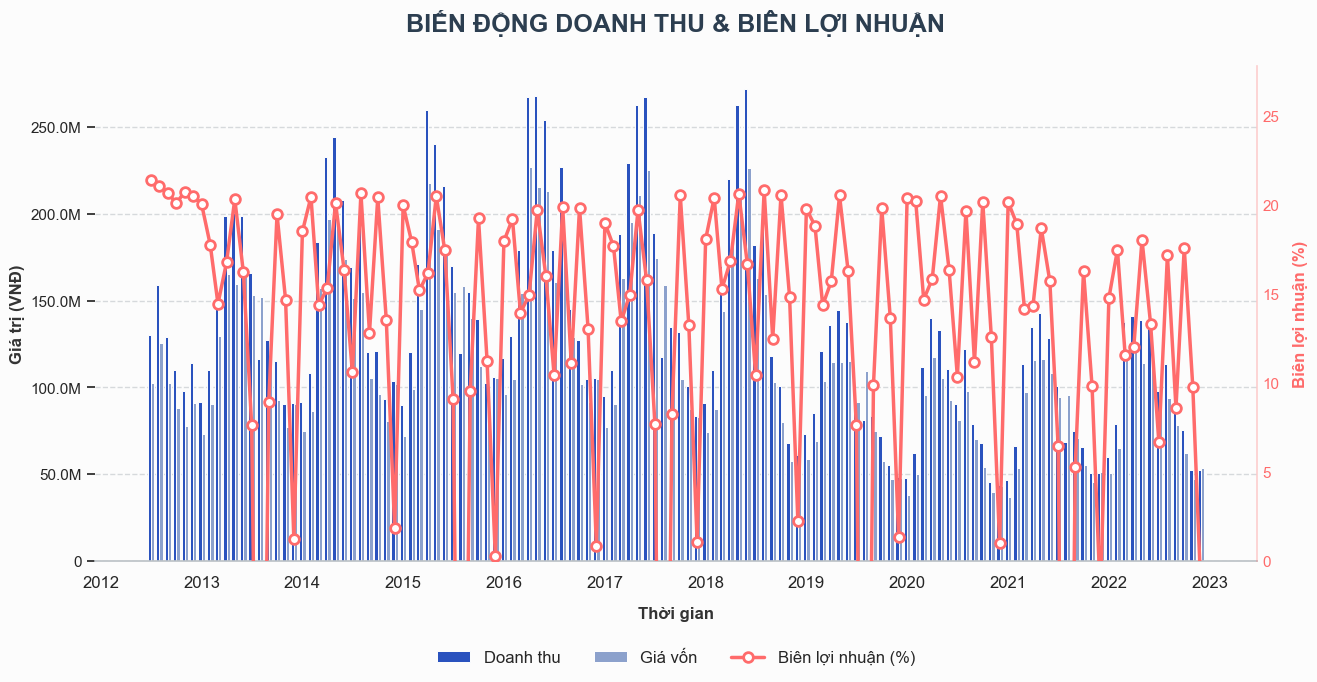

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

# ==========================================
# HÀM FORMAT TIỀN TỆ CHUNG (M/B ĐỒNG)
# ==========================================
def format_vnd_modern(val, pos):
    if val >= 1e9:
        return f"{val/1e9:.1f}B đ"
    elif val >= 1e6:
        return f"{val/1e6:.1f}M đ"
    else:
        return f"{val:,.0f} đ"

# Cài đặt giao diện chung
sns.set_theme(style="white", rc={"axes.facecolor": "#fcfcfc", "figure.facecolor": "#fcfcfc"})

# ==============================================================================
# CHỦ ĐỀ 1: BIÊN LỢI NHUẬN (PROFIT MARGIN) - Đánh giá hiệu quả quản lý chi phí
# ==============================================================================
try:
    sales_df = pd.read_csv('../dataset/sales.csv')
    sales_df['Date'] = pd.to_datetime(sales_df['Date'])
    monthly_sales = sales_df.resample('MS', on='Date')[['Revenue', 'COGS']].sum().reset_index()
    
    monthly_sales['Gross_Profit'] = monthly_sales['Revenue'] - monthly_sales['COGS']
    monthly_sales['Profit_Margin_%'] = (monthly_sales['Gross_Profit'] / monthly_sales['Revenue']) * 100

    fig1, ax1 = plt.subplots(figsize=(15, 7.5))
    width = 12 
    x = monthly_sales['Date']

    color_revenue = '#2A52BE' # Xanh hoàng gia
    color_cogs = '#8CA1CC'    # Xanh nhạt
    color_margin = '#FF6B6B'  # Đỏ san hô

    ax1.bar(x - pd.Timedelta(days=6), monthly_sales['Revenue'], width=width, label='Doanh thu tổng', color=color_revenue, edgecolor='white', linewidth=0.7)
    ax1.bar(x + pd.Timedelta(days=6), monthly_sales['COGS'], width=width, label='Chi phí tổng (COGS)', color=color_cogs, edgecolor='white', linewidth=0.7)

    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(format_vnd_modern))
    ax1.set_ylabel('Giá trị (VNĐ)', fontsize=12, fontweight='bold', color='#333333')
    ax1.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax1.set_axisbelow(True) 

    # Trục X timeline
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax1.tick_params(axis='x', which='major', labelsize=12, pad=10, length=0)
    ax1.xaxis.set_minor_locator(mdates.MonthLocator())
    ax1.tick_params(axis='x', which='minor', length=5, color='#bdc3c7', width=1.5) 
    ax1.set_xlabel('Thời gian', fontsize=12, fontweight='bold', labelpad=12, color='#333333')

    # Dọn dẹp viền
    for spine in ['top', 'right', 'left']:
        ax1.spines[spine].set_visible(False)
    ax1.spines['bottom'].set_color('#bdc3c7')

    # Đường Profit Margin
    ax2 = ax1.twinx()
    ax2.plot(x, monthly_sales['Profit_Margin_%'], color=color_margin, marker='o', 
             mfc='white', mec=color_margin, mew=2, linewidth=2.5, markersize=7, 
             label='Biên lợi nhuận (%)')
    ax2.set_ylabel('Biên lợi nhuận (%)', fontsize=12, fontweight='bold', color=color_margin, labelpad=10)
    ax2.tick_params(axis='y', labelcolor=color_margin, length=0)
    ax2.grid(False)
    for spine in ['top', 'left', 'bottom']:
        ax2.spines[spine].set_visible(False)
    ax2.spines['right'].set_color(color_margin)
    ax2.spines['right'].set_alpha(0.3)
    ax2.set_ylim(0, monthly_sales['Profit_Margin_%'].max() * 1.3) 

    # Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=12)

    plt.title('1. BIÊN LỢI NHUẬN (PROFIT MARGIN) THEO THỜI GIAN', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.22)
    plt.show()

except FileNotFoundError:
    print("Không tìm thấy file ../dataset/sales.csv")


# ==============================================================================
# CHỦ ĐỀ 2: LỢI NHUẬN CẬN BIÊN (MARGINAL PROFIT) - Quyết định sản lượng/sản phẩm
# ==============================================================================
try:
    products_df = pd.read_csv('../dataset/products.csv')
    
    # Tính Lợi nhuận cận biên (Mπ = Giá bán - Giá vốn)
    products_df['Marginal_Profit'] = products_df['price'] - products_df['cogs']
    
    # Lấy top 10 sản phẩm có lợi nhuận cận biên cao nhất để biểu diễn
    top_products = products_df.sort_values(by='Marginal_Profit', ascending=False).head(10)

    fig2, ax3 = plt.subplots(figsize=(15, 7.5))
    x_prod = np.arange(len(top_products))
    width_prod = 0.25

    color_price = '#2A52BE' # Xanh hoàng gia (MR)
    color_cost = '#8CA1CC'  # Xanh nhạt (MC)
    color_mp = '#00b894'    # Xanh lá (Lợi nhuận cận biên)

    ax3.bar(x_prod - width_prod, top_products['price'], width_prod, label='Doanh thu cận biên (Giá bán)', color=color_price, edgecolor='white')
    ax3.bar(x_prod, top_products['cogs'], width_prod, label='Chi phí cận biên (Giá vốn)', color=color_cost, edgecolor='white')
    ax3.bar(x_prod + width_prod, top_products['Marginal_Profit'], width_prod, label='Lợi nhuận cận biên (Mπ)', color=color_mp, edgecolor='white')

    ax3.yaxis.set_major_formatter(ticker.FuncFormatter(format_vnd_modern))
    ax3.set_ylabel('Giá trị / 1 Đơn vị (VNĐ)', fontsize=12, fontweight='bold', color='#333333')
    ax3.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
    ax3.set_axisbelow(True)

    # Rút gọn tên sản phẩm dài
    short_names = [str(name)[:15] + '...' if len(str(name)) > 15 else str(name) for name in top_products['product_name']]
    ax3.set_xticks(x_prod)
    ax3.set_xticklabels(short_names, rotation=30, ha='right', fontsize=11)
    
    # Dọn dẹp viền
    for spine in ['top', 'right', 'left']:
        ax3.spines[spine].set_visible(False)
    ax3.spines['bottom'].set_color('#bdc3c7')

    # Gắn nhãn giá trị lợi nhuận trực tiếp lên cột
    for i, val in enumerate(top_products['Marginal_Profit']):
        formatted_val = format_vnd_modern(val, None)
        ax3.text(i + width_prod, val + (val * 0.02), f'+{formatted_val}', ha='center', va='bottom', fontweight='bold', color=color_mp, fontsize=10)

    ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=12)

    plt.title('2. LỢI NHUẬN CẬN BIÊN (MARGINAL PROFIT) - TOP 10 SẢN PHẨM', fontsize=16, fontweight='900', pad=25, color='#2c3e50')
    plt.subplots_adjust(bottom=0.3)
    plt.show()

except FileNotFoundError:
    print("Không tìm thấy file ../dataset/products.csv")